In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
def k_fold_cv(X,y,k=5,n_neighbors=3):
    fold_size = len(X) // k
    accuracies = []
    for i in range(k):
        start = i * fold_size
        end = (i+i)* fold_size
        X_test, y_test = X[start:end], y[start:end]
        X_train = np.vstack([X[:start], X[end:]])
        y_train = np.hstack([y[:start], y[end:]])
        knn=KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    return np.mean(accuracies)



In [3]:
def k_fold_cv(X,y,k=5,n_neighbors=3):
    fold_size = len(X) // k
    accuracies = []
    for i in range(k):
        start = i * fold_size
        end = (i+1)* fold_size  # Corrected line
        X_test, y_test = X[start:end], y[start:end]
        X_train = np.vstack([X[:start], X[end:]])
        y_train = np.hstack([y[:start], y[end:]])
        knn=KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    return np.mean(accuracies)

avg_accuracy = k_fold_cv(X,y,k=5)
print(f"Average k-NN accuracy (k-Fold CV): {avg_accuracy:.3f}")

Average k-NN accuracy (k-Fold CV): 0.907


In [4]:
def bootstrap_regression(X,y,n_bootstraps=1000):
    n_samples = len(X)
    coefs=[]
    model = LinearRegression() # Initialize the model here
    for _ in range(n_bootstraps):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        X_boot = X[indices]
        y_boot = y[indices]
        model.fit(X_boot, y_boot)
        coefs.append(model.coef_)
    return np.array(coefs)
X_reg=X[:,:2]
y_reg=X[:,2]
coefs=bootstrap_regression(X_reg,y_reg,n_bootstraps=500)
print(coefs)

[[ 1.75574945 -1.4162298 ]
 [ 1.82367547 -1.24943076]
 [ 1.69217177 -1.42068543]
 [ 1.70216913 -1.50365044]
 [ 1.80898034 -1.44052788]
 [ 1.79156872 -1.49730153]
 [ 1.67083068 -1.51392819]
 [ 1.71593492 -1.40334429]
 [ 1.72779103 -1.41873726]
 [ 1.91803664 -1.30148548]
 [ 1.68933735 -1.56173814]
 [ 1.72750626 -1.36694994]
 [ 1.87931155 -1.43651578]
 [ 1.81154525 -1.23624433]
 [ 1.85703583 -1.3604389 ]
 [ 1.78157932 -1.45754818]
 [ 1.75582872 -1.41122283]
 [ 1.75851758 -1.18471193]
 [ 1.79766172 -1.30358857]
 [ 1.82866355 -1.08711072]
 [ 1.79587182 -1.38290422]
 [ 1.72929402 -1.37223312]
 [ 1.8011484  -1.09853044]
 [ 1.79246478 -1.33734063]
 [ 1.81707688 -1.17721954]
 [ 1.63659875 -1.6416658 ]
 [ 1.88292143 -1.49801764]
 [ 1.8261267  -1.20652565]
 [ 1.64241388 -1.42623183]
 [ 1.88755454 -1.27461148]
 [ 1.90373719 -1.32775459]
 [ 1.75120022 -1.32757144]
 [ 1.77291047 -1.57816048]
 [ 1.66515953 -1.45700104]
 [ 1.8220956  -1.2728338 ]
 [ 1.76715652 -1.36809974]
 [ 1.85713455 -1.3353096 ]
 

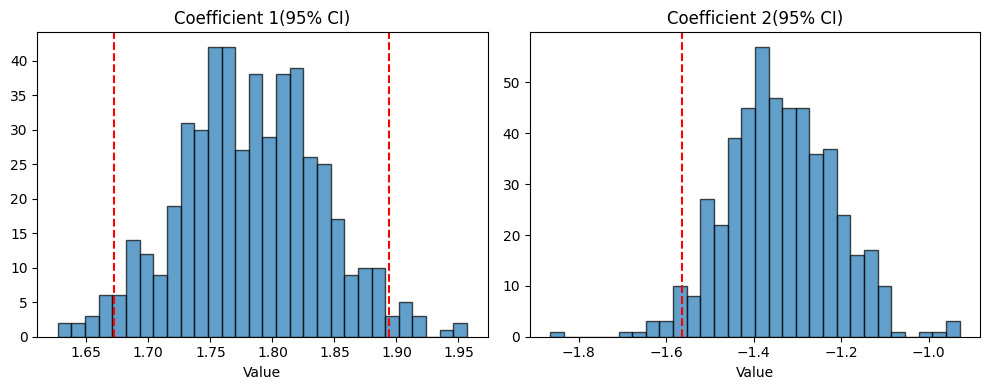


Bootstrap results(95% confidence intervals):
Coefficient 1: 1.673 - 1.894
Coefficient 2: -1.563 - -1.099


In [5]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(coefs[:,0],bins=30,alpha=0.7,edgecolor='black')
plt.axvline(np.percentile(coefs[:,0], 2.5), color='red', linestyle='--')
plt.axvline(np.percentile(coefs[:,0], 97.5), color='red', linestyle='--')
plt.title('Coefficient 1(95% CI)')
plt.xlabel('Value')
plt.subplot(1,2,2)
plt.hist(coefs[:,1],bins=30,alpha=0.7,edgecolor='black')
plt.axvline(np.percentile(coefs[:,1], 2.5), color='red', linestyle='--')
plt.title('Coefficient 2(95% CI)')
plt.xlabel('Value')
plt.tight_layout()
plt.show()
print(f"\nBootstrap results(95% confidence intervals):")
for i in range(coefs.shape[1]):
    lower = np.percentile(coefs[:,i], 2.5)
    upper = np.percentile(coefs[:,i], 97.5)
    print(f"Coefficient {i+1}: {lower:.3f} - {upper:.3f}")

In [6]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

def k_fold_cv(X, y, k=5, n_neighbors=3):
    fold_size = len(X) // k
    accuracies = []

    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size

        X_test = X[start:end]
        y_test = y[start:end]

        X_train = np.vstack((X[:start], X[end:]))
        y_train = np.hstack((y[:start], y[end:]))

        model = KNeighborsClassifier(n_neighbors=n_neighbors)
        model.fit(X_train, y_train)

        predictions = model.predict(X_test)
        acc = accuracy_score(y_test, predictions)
        accuracies.append(acc)

        print(f"Fold {i+1} Accuracy: {acc:.3f}")

    return np.mean(accuracies)


average_accuracy = k_fold_cv(X, y, k=5)
print("Average k-NN Accuracy:", average_accuracy)

Fold 1 Accuracy: 1.000
Fold 2 Accuracy: 1.000
Fold 3 Accuracy: 0.833
Fold 4 Accuracy: 0.933
Fold 5 Accuracy: 0.767
Average k-NN Accuracy: 0.9066666666666666
